In [1]:
print('hi')

hi



0: 384x640 28 peoples, 546.2ms
1: 384x640 27 peoples, 546.2ms
2: 384x640 27 peoples, 546.2ms
3: 384x640 27 peoples, 546.2ms
4: 384x640 27 peoples, 546.2ms
5: 384x640 28 peoples, 546.2ms
6: 384x640 30 peoples, 546.2ms
7: 384x640 28 peoples, 546.2ms
8: 384x640 25 peoples, 546.2ms
9: 384x640 29 peoples, 546.2ms
10: 384x640 27 peoples, 546.2ms
Speed: 7.5ms preprocess, 546.2ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


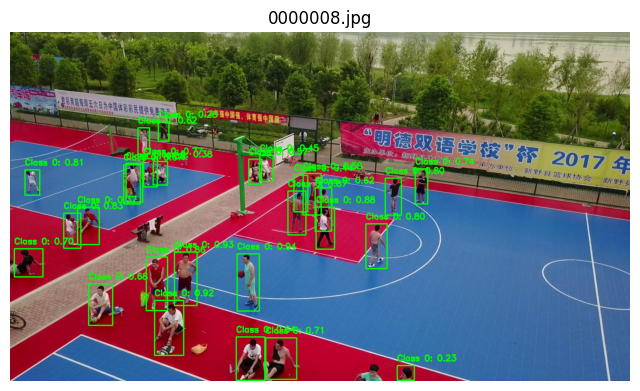

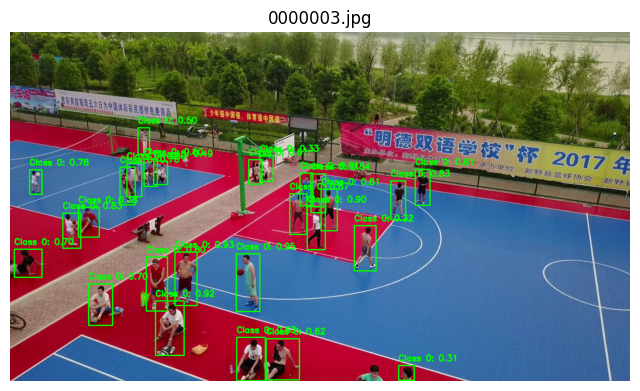

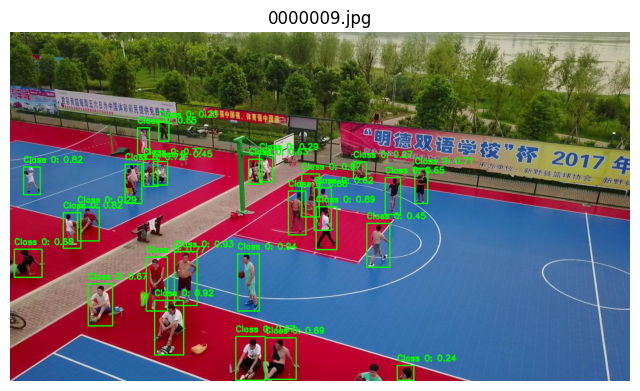

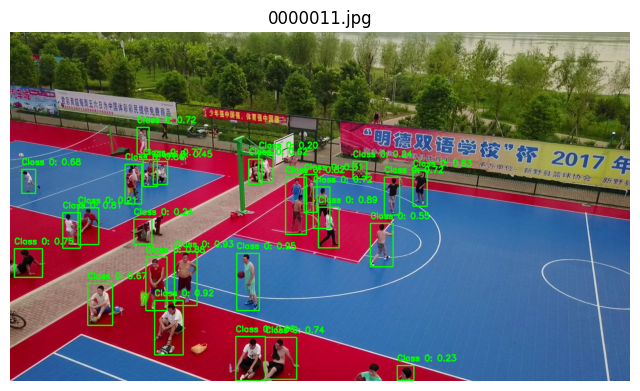

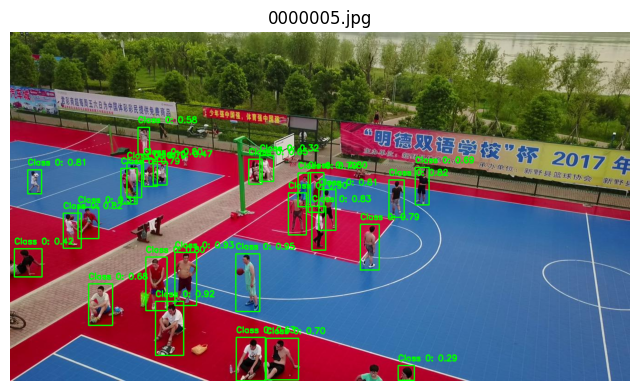

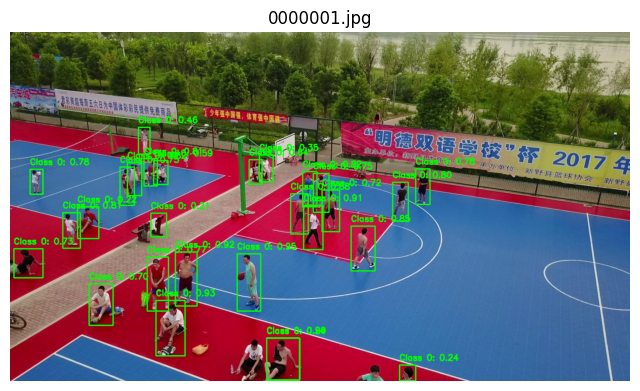

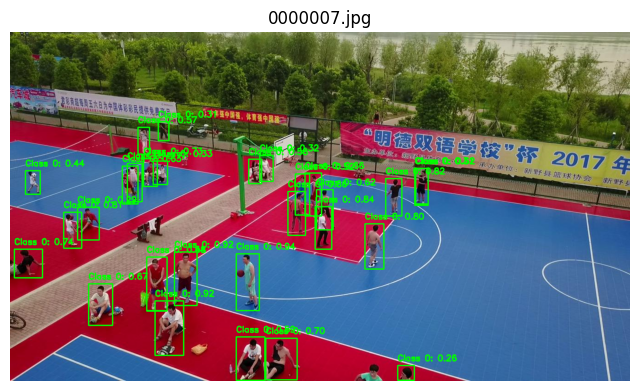

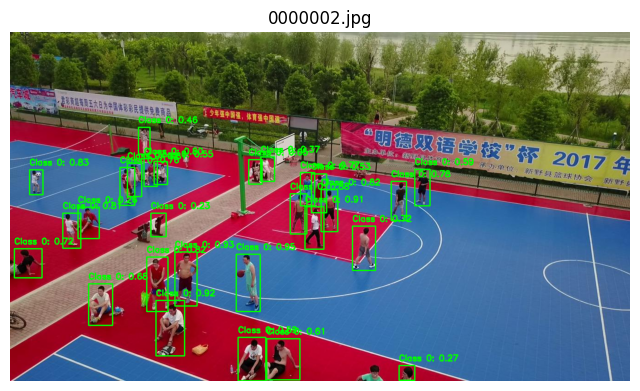

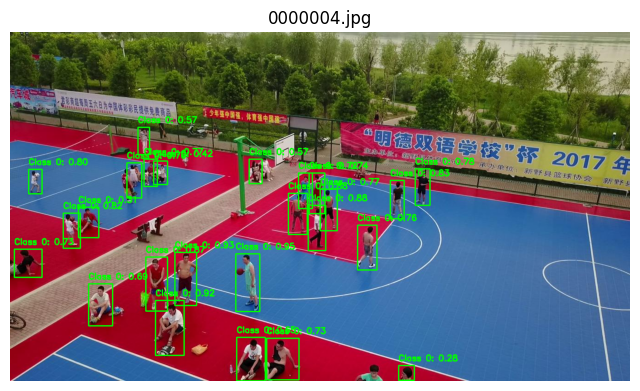

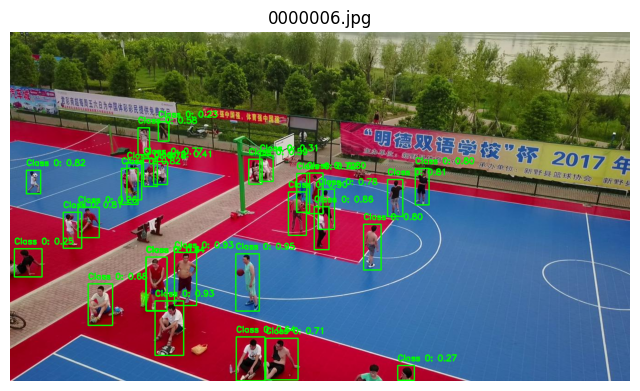

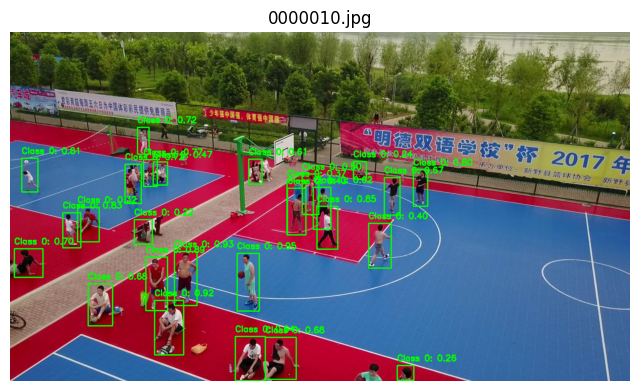

In [4]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os
from glob import glob

# Load YOLOv8 model
model = YOLO("/home/rahul/Projects/aerial_guardian/mot_results/runs/detect/train/weights/best.pt")   # replace with your model path

# Folder containing images
image_folder = "images1"   # replace with your folder

# Get all image paths
image_paths = glob(os.path.join(image_folder, "*.*"))

# Run inference on all images
results = model(image_paths, conf=0.2, iou=0.45)

# Display results
for img_path, result in zip(image_paths, results):

    # Read image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Draw only class 0 detections
    for box in result.boxes:
        cls_id = int(box.cls[0])

        if cls_id == 0:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            conf = float(box.conf[0])

            # Draw box
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

            # Label
            label = f"Class 0: {conf:.2f}"
            cv2.putText(
                img,
                label,
                (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 0),
                2
            )

    # Show image
    plt.figure(figsize=(8, 8))
    plt.title(os.path.basename(img_path))
    plt.imshow(img)
    plt.axis("off")
    plt.show()